In [1]:
import os

In [2]:
def load_config():
    output_config = {
        "OPENAI_API_KEY": os.getenv("OPENAI_API_KEY"),
        "LANGSMITH_API_KEY":os.getenv("LANGSMITH_API_KEY"),
        "LANGSMITH_TRACING_V2":os.getenv("LANGSMITH_TRACING_V2"),
        "LANGSMITH_ENDPOINT":os.getenv("LANGSMITH_ENDPOINT"),
        "MODEL_NAME": "openai:gpt-5-mini",
        "PROJECT_NAME": "LangchainAcademy",
        "DB_PATH": "Chinook.db"
    }
    os.environ["LANGSMITH_PROJECT"] = output_config["PROJECT_NAME"]
    return output_config


In [3]:
from langgraph.graph import END,START,StateGraph
from langgraph.types import Command
from typing import Annotated, List, Literal, TypedDict

In [4]:
import operator


 - State: All nodes share the same state which can be a Python TypedDict, dataclass, or a Pydantic BaseModel
 - Nodes: Defined as simple Python functions that receive state as input and return updated state
 - Runtime: When you call invoke, the graph initializes the input state from your invoke statement and determines which nodes to run
 - State Flow: Each node receives the current state as input, executes its logic, and returns an updated state
 - Graph Return: After all nodes complete execution, the graph returns the final state value


# simple static edge

In [4]:
class State(TypedDict):
    nlist:List[str]

In [5]:
def node_a(state):
    note = 'Hello world from Node a'
    return State(nlist=[note])

In [6]:
builder = StateGraph(State)
builder.add_node('a',node_a)

builder.add_edge(START,'a')
builder.add_edge('a',END)
graph = builder.compile()

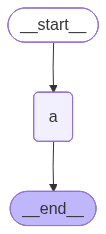

In [7]:
graph

In [8]:
initial_state = State(nlist=['InitialState'])
graph.invoke(initial_state)

{'nlist': ['Hello world from Node a']}

 - LangGraph enables parallel execution when a node has multiple outgoing edges.
 - reducer to accumulate results from parallel branches.

# static parallel edges

In [9]:
class State(TypedDict):
    nlist: Annotated[List[str],operator.add]

In [10]:
def node_a(state: State) -> State:
    print(f"Adding 'A' to {state['nlist']}")
    return(State(nlist = ["A"]))

def node_b(state: State) -> State:
    print(f"Adding 'B' to {state['nlist']}")
    return(State(nlist = ["B"]))

def node_c(state: State) -> State:
    print(f"Adding 'C' to {state['nlist']}")
    return(State(nlist = ["C"]))

def node_bb(state: State) -> State:
    print(f"Adding 'BB' to {state['nlist']}")
    return(State(nlist = ["BB"]))

def node_cc(state: State) -> State:
    print(f"Adding 'CC' to {state['nlist']}")
    return(State(nlist = ["CC"]))

def node_d(state: State) -> State:
    print(f"Adding 'D' to {state['nlist']}")
    return(State(nlist = ["D"]))

def node_f(state:State) ->State:
    print(f"Adding 'F' to {state['nlist']}")
    return (State(nlist = ["F"]))

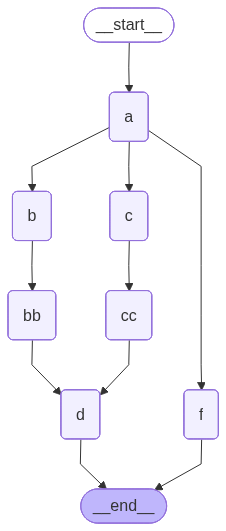

In [11]:
builder = StateGraph(State)

# adding nodes 
builder.add_node('a',node_a)
builder.add_node('b',node_b)
builder.add_node('f',node_f)
builder.add_node('c',node_c)
builder.add_node('bb',node_bb)
builder.add_node('cc',node_cc)
builder.add_node('d',node_d)

# adding edges
builder.add_edge(START,'a')
builder.add_edge('a','b')
builder.add_edge('a','c')
builder.add_edge('a','f')
builder.add_edge('b','bb')
builder.add_edge('c','cc')
builder.add_edge('bb','d')
builder.add_edge('cc','d')
builder.add_edge('d',END)

graph = builder.compile()
graph

In [12]:
initial_state = State(nlist = ['INIT']) 
graph.invoke(initial_state)

Adding 'A' to ['INIT']
Adding 'B' to ['INIT', 'A']
Adding 'C' to ['INIT', 'A']
Adding 'F' to ['INIT', 'A']
Adding 'BB' to ['INIT', 'A', 'B', 'C', 'F']
Adding 'CC' to ['INIT', 'A', 'B', 'C', 'F']
Adding 'D' to ['INIT', 'A', 'B', 'C', 'F', 'BB', 'CC']


{'nlist': ['INIT', 'A', 'B', 'C', 'F', 'BB', 'CC', 'D']}

# dynamic edge

In [13]:
class State(TypedDict):
    nlist:Annotated[list[str],operator.add]

In [14]:
# without using the dynamic edge function 
# def node_a(state:State):
#     select = state['nlist'][-1]
#     if select =='b':
#         next_node='b'
#     elif select =='c':
#         next_node='c'
#     elif select=='q':
#         next_node=END
#     else:
#         next_node=END
#     return Command(
#         # update = State(nlist=[select]),
#         goto = [next_node]
#     )

In [15]:
def node_a(state:State):
    return 
def node_b(state:State) -> State:
    return (State(nlist=['Node B Update']))
def node_c(state:State) -> State:
    return (State(nlist = ['Node C update']))

In [16]:
def conditional_edge(state: State) -> Literal["b","c",END]:
    select = state["nlist"][-1]
    if select == "b":
        return "b"
    elif select == "c":
        return "c"
    elif select == "q":
        return END
    else:
        return END

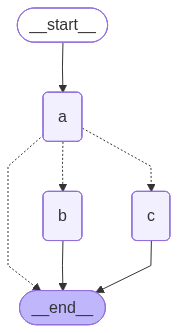

In [17]:
builder = StateGraph(State)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

# Add edges
builder.add_edge(START, "a")
builder.add_edge("b", END)
builder.add_edge("c", END)
builder.add_conditional_edges("a", conditional_edge)

# Compile and display
graph = builder.compile()
graph

In [18]:
user = input('b,c, or q to quit: ')
input_state = State(nlist = [user])
graph.invoke(input_state)

b,c, or q to quit:  b


{'nlist': ['b', 'Node B Update']}

# memory

In [19]:
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
config = {'configurable':{'thread_id':'1'}}

In [20]:
graph = builder.compile(checkpointer = memory)

In [21]:
while True:
    user = input('Provide b  or c or q') 
    input_state = State(nlist=[user])
    result = graph.invoke(input_state,config)
    print(result)
    if result['nlist'][-1] =='q':
        print('quitting')
        break 

Provide b  or c or q b


{'nlist': ['b', 'Node B Update']}


Provide b  or c or q b


{'nlist': ['b', 'Node B Update', 'b', 'Node B Update']}


Provide b  or c or q c


{'nlist': ['b', 'Node B Update', 'b', 'Node B Update', 'c', 'Node C update']}


Provide b  or c or q q


{'nlist': ['b', 'Node B Update', 'b', 'Node B Update', 'c', 'Node C update', 'q']}
quitting


# interrupt

In [29]:
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
config = {'configurable':{'thread_id':"1"}}

In [30]:
class State(TypedDict):
    nlist: Annotated[list[str],operator.add]

In [35]:
def node_a(state: State) -> Command[Literal["b", "c", END]]:
    print("Entered 'a' node")
    select = state["nlist"][-1]
    if select == "b":
        next_node = "b"
    elif select == "c":
        next_node = "c"
    elif select == "q":
        next_node = END
    else:
        admin = interrupt(f"Unexpected input '{select}'")
        print(admin)
        if admin == "continue":
            next_node = "b"
        else:
            next_node = END
            select = "q"
            
    return Command(
        # update = State(nlist = [select]),
        goto = next_node
    )


def node_b (state: State) -> State:
    return(State(nlist = ["B"]))

def node_c (state: State) -> State:
    return(State(nlist = ["C"]))


In [36]:
builder = StateGraph(State)

# Add nodes
builder.add_node("a", node_a)
builder.add_node("b", node_b)
builder.add_node("c", node_c)

# Add edges
builder.add_edge(START,"a")
builder.add_edge("b", END)
builder.add_edge("c", END)

# Compile
graph = builder.compile(checkpointer=memory)

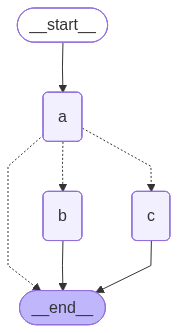

In [37]:
graph

In [38]:
while True:
    user = input('b, c, or q to quit: ')
    input_state = State(nlist = [user])
    result = graph.invoke(input_state, config)

    if '__interrupt__' in result:
        print(f"Interrupt:{result}")
        msg = result['__interrupt__'][-1].value
        print(msg)
        human = input(f"\n{msg}: ")

        human_response = Command(
            resume = human
        )
        result = graph.invoke(human_response, config)
        
    if result['nlist'][-1] == "q":
        print("quit")
        break

b, c, or q to quit:  b


Entered 'a' node


b, c, or q to quit:  b


Entered 'a' node


b, c, or q to quit:  c


...

Entered 'a' node
Interrupt:{'nlist': ['b', 'b', 'B', 'c', 'c', 'C', 'u', 'u', 'B', 'q', 'q', 'b', 'B', 'b', 'B', 'c', 'C', 'b', 'B', 'y', 'k'], '__interrupt__': [Interrupt(value="Unexpected input 'k'", id='711a8ebb743606bcc73064d0f01b4009')]}
Unexpected input 'k'



Unexpected input 'k':  k


Entered 'a' node
k


b, c, or q to quit:  q


Entered 'a' node
quit


# EMAIL Support WorkFlow
 - state, nodes, edges ( serial, parallel, conditional)
 - Memory
 - Interrupt

In [40]:
from dotenv import load_dotenv
from pathlib import Path
import os

load_dotenv(".env", override=True)
os.environ.pop("LANGCHAIN_ENDPOINT", None)  # safety
print(os.getenv("LANGSMITH_ENDPOINT"))

from langgraph.graph import END,START,StateGraph
from langgraph.types import Command,interrupt
from typing import Annotated, List, Literal, TypedDict

from IPython.display import Image,display
import operator
import uuid

https://api.smith.langchain.com


In [46]:
class EmailClassification(TypedDict):
    intent : Literal['question','bug','billing','feature','complex']
    urgency: Literal['low','medium','high','critical']
    topic : str
    summary : str

class EmailAgentState(TypedDict):
    email_content: str
    sender_email : str
    email_id : str
    classification : EmailClassification | None 
    ticket_id : str | None
    search_results: list[str] | None
    customer_history : dict | None
    draft_response : str | None 

In [47]:
from langchain_openai import ChatOpenAI
from langgraph.types import Command, interrupt
from langgraph.graph import END,START, StateGraph

def read_email(state:EmailAgentState) -> EmailAgentState:
    """Extract and parse email content"""
    pass

llm = ChatOpenAI(model="gpt-5-mini")

def classify_intent(state:EmailAgentState) -> EmailAgentState:
    """
    Use LLM to classify email intent and urgency, then route accordingly
    """

    structured_llm = llm.with_structured_output(EmailClassification)
    classification_prompt = f"""
    Analyse this customer email and classify it:
    
    Email : {state['email_content']}
    From : {state['sender_email']}

    Provide classification, include intent, urgency,topic, and summary
    """

    classification = structured_llm.invoke(classification_prompt)

    return {'classification':classification}

def search_documentation(state:EmailAgentState) -> EmailAgentState:
    """
    Search knowledge base for relevant information
    """
    classification = state.get('classification',{})
    query = f"{classification.get('intent','')} {classification.get('topic','')}"

    try:
        search_results = [
            "__search_result_1__",
            "__search_result_2__",
            "__search_result_3__",
        ]
    except SearchAPIError as e:
        search_results = [f"Search temporarily unavailable: {str[e]}"]
    return {"search_results": search_results}


def bug_tracking(state: EmailAgentState) -> EmailAgentState:
    """Create or update bug tracking ticket"""

    # Create ticket in your bug tracking system
    ticket_id = f"BUG_{uuid.uuid4()}"

    return {"ticket_id": ticket_id}

def write_response(state: EmailAgentState) -> Command[Literal["human_review", "send_reply"]]:
    "Generate response using context and route based on quality"""

    classification = state.get('classification', {})

    # Format context from raw state data on demand
    context_sections = []

    if state.get('search_results'):
        # Format search results for the prompt
        formatted_docs = "\n".join([f"- {doc}" for doc in state['search_results']])
        context_sections.append(f"Relevant documentation:\n{formatted_docs}")

    if state.get('customer_history'):
        # Format customer data for the prompt
        context_sections.append(f"Customer tier: {state['customer_history'].get('tier', 'standard')}")

    # Build the prompt with formatted context
    draft_prompt = f"""
    Draft a response to this customer email:
    {state['email_content']}

    Email intent: {classification.get('intent', 'unkown')}
    Urgency level: {classification.get('urgency', 'medium')}

    {chr(10).join(context_sections)}

    Guidelines:
    - Be professional and helpful
    - Address their specific concern
    - Use the provided documentation when relevant
    - Be brief
    """

    response = llm.invoke(draft_prompt)

    # Determine if human review is needed based on urgency and intent
    needs_review = (
        classification.get('urgency') in ['high', 'critical'] or
        classification.get('intent') == 'complex'
    )

    # Route to the appropriate next node
    if needs_review:
        goto = "human_review"
        print("Needs approval")
    else:
        goto = "send_reply"

    return Command(
        update = {"draft_response": response.content},
        goto = goto
    )

def human_review(state: EmailAgentState) -> Command[Literal["send_reply", END]]:
    """Pause for human review using interrupt and route based on decision"""

    classification = state.get('classification', {})

    # Interrupt() must come first - any code before it will re-run on resume
    human_decision = interrupt({
        "email_id": state['email_id'],
        "original_email": state['email_content'],
        "draft_response": state.get('draft_response', ""),
        "urgency": classification.get('urgency'),
        "intent": classification.get('intent'),
        "action": "Please review and approve/edit this response"
    })

    # Now process the human's decision
    if human_decision.get("approved"):
        return Command(
            update = {"draft_response": human_decision.get("edited_response", state['draft_response'])},
            goto = "send_reply"
        )
    else:
        # Rejection means human will handle directly
        return Command(update = {}, goto = END)

def send_reply(state: EmailAgentState) -> EmailAgentState:
    """Send the email response"""
    # Integrate with a email service
    print(f"Sending reply: {state['draft_response'][:60]}...")
    return {}

In [48]:
# Create the graph
builder = StateGraph(EmailAgentState)

# Add nodes
builder.add_node("read_email", read_email)
builder.add_node("classify_intent", classify_intent)
builder.add_node("search_documentation", search_documentation)
builder.add_node("bug_tracking", bug_tracking)
builder.add_node("write_response", write_response)
builder.add_node("human_review", human_review)
builder.add_node("send_reply", send_reply)

# Add edges
builder.add_edge(START, "read_email")
builder.add_edge("read_email", "classify_intent")
builder.add_edge("classify_intent", "search_documentation")
builder.add_edge("classify_intent", "bug_tracking")
builder.add_edge("search_documentation", "write_response")
builder.add_edge("bug_tracking", "write_response")
builder.add_edge("send_reply", END)

# Compile with checkpointer for persistence
from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
app = builder.compile(checkpointer = memory)

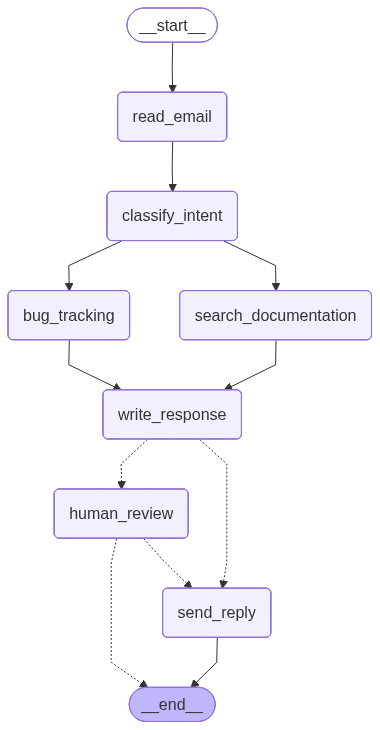

In [49]:
app

In [50]:
# Test with urgent billing issue
initial_state = {
    "email_content": "I was charged twice for my subscription! This is urgent!",
    "sender_email": "customer@example.com",
    "email_id": "email_123"
}

# Run with a thread_id for persistence
config = {"configurable": {"thread_id": "customer_123"}}
result = app.invoke(initial_state, config)


Needs approval


In [52]:
# The graph will pause at human_review
print(f"Draft ready for review: {result['draft_response']}...\n")

# Provide human input to resume
human_response = Command(
    resume = {
        "approved": True
    }
)

# Resume execution
final_result = app.invoke(human_response, config)
print("Email sent successfully!")

Draft ready for review: Hi — I’m sorry about the double charge and I’ll get this fixed right away.

To investigate and resolve this ASAP, please reply with:
- the email address on the account (or customer ID)  
- date(s) and amount(s) of the charge(s)  
- the last 4 digits of the card used (or a screenshot of the charge on your bank/statement)

I will review your account and our billing records (see __search_result_1__ and __search_result_2__), confirm whether a duplicate charge posted, and — if confirmed — issue a refund or credit per our billing procedures (__search_result_3__). I’ll update you within 24 hours. Refunds typically appear on bank statements within a few business days once processed.

Again, I’m sorry for the inconvenience. Please send the details above and I’ll start the investigation immediately.

Thanks,  
[Your name]  
Billing Support...

Email sent successfully!


In [53]:
email_content = [
    "I was charged two times for my subscription! This is urgent!",
    "I was wondering if this was available in blue?",
    "Can you tell me how long the sale is on?",
    "The tire won't stay on the car!",
    "My subscription is going to end in a few months, what is the new rate?"
]
needs_approval = []

for i, content in enumerate(email_content): 

    initial_state = {
        "email_content": content,
        "sender_email": "customer@example.com",
        "email_id": f"email_{i}",
    }
    print(f"{initial_state['email_id']}: ", end="")

    thread_id = uuid.uuid4()
    config =  {"configurable": {"thread_id": thread_id}}
    result = app.invoke(initial_state, config)
    if "__interrupt__" in result.keys():
        result['thread_id'] = thread_id
        needs_approval.append(result)


email_0: Needs approval
email_1: Sending reply: Hi —

Thanks for checking. Could you tell me which product y...
email_2: Sending reply: Thanks for asking — I can confirm that. Which sale are you r...
email_3: Needs approval
email_4: Sending reply: Hi [Name],

Thanks — I can help. Renewal pricing depends on ...
